# Validações Estatísticas do BeamNG como Digital Twin — v5

Análise com métricas **globais** (sem janela deslizante):
- **Pearson r**: correlação linear entre as séries completas
- **DTW**: distância de similaridade entre as séries completas
- **ANOVA**: teste de igualdade de distribuição por segmentos fixos do percurso

## 1. Imports

In [1]:
try:
    from dtaidistance import dtw, dtw_ndim
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'dtaidistance', '-q'])
    from dtaidistance import dtw, dtw_ndim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr, f_oneway
from scipy.signal import correlate, detrend
from sklearn.preprocessing import MinMaxScaler
from os import listdir
import ast
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
print('OK')

OK


## 2. Funções auxiliares

In [2]:
def latlon_para_metros(lat, lon):
    R = 6_371_000.0
    lat0, lon0 = np.radians(lat[0]), np.radians(lon[0])
    x = R * (np.radians(lon) - lon0) * np.cos(lat0)
    y = R * (np.radians(lat) - lat0)
    return x, y

def parse_vel(s):
    try:
        v = ast.literal_eval(str(s))
        return float(np.linalg.norm(v))
    except Exception:
        return np.nan

## 3. Carregar dados

In [3]:
reais = []
for file in sorted(listdir('circuito4/real')):
    reais.append(pd.read_csv(f'circuito4/real/{file}', sep=',', skipinitialspace=True))
print(f'Reais carregados: {len(reais)}')

simulados = []
for file in sorted(listdir('circuito4/simulado_taxa_coleta_correta')):
    simulados.append(pd.read_csv(f'circuito4/simulado_taxa_coleta_correta/{file}', sep=';'))
print(f'Simulados carregados: {len(simulados)}')

Reais carregados: 10
Simulados carregados: 1


## 4. Preparação dos dados

In [4]:
def preparar_real(df, freq='100ms'):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df = df.sort_values('Time (sec)').reset_index(drop=True)
    df['time'] = pd.to_timedelta(df['Time (sec)'], unit='s')
    df = df.set_index('time')
    df = df.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')

    x_m, y_m = latlon_para_metros(df['Latitude (deg)'].values, df['Longitude (deg)'].values)
    df['posX'] = x_m
    df['posY'] = y_m
    df['posZ'] = detrend(df['Altitude (m)'].values, type='linear')
    df = df.rename(columns={'Posição D do pedal do acelerador (%)': 'throttle'})

    if 'Velocidade do veículo (km/h)' in df.columns:
        df['vel'] = df['Velocidade do veículo (km/h)'] / 3.6
    elif 'Velocidade do GPS (km/h)' in df.columns:
        df['vel'] = df['Velocidade do GPS (km/h)'] / 3.6

    df = df.resample(freq).mean().interpolate(method='time')
    df.index = df.index - df.index[0]
    return df


def preparar_simulado(df, freq='100ms'):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df = df.rename(columns={df.columns[0]: 'time'})
    df = df.sort_values('time').reset_index(drop=True)
    df['time'] = pd.to_timedelta(df['time'] - df['time'].iloc[0], unit='s')
    df = df.set_index('time')

    if 'vel' in df.columns:
        df['vel'] = df['vel'].apply(parse_vel)

    df = df.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')

    if 'posZ' in df.columns:
        df['posZ'] = detrend(df['posZ'].values, type='linear')

    df = df.resample(freq).mean().interpolate(method='time')

    if 'vel' in df.columns:
        df['vel'] = df['vel'].rolling(window=10, center=True, min_periods=1).mean()

    df.index = df.index - df.index[0]
    return df


real     = preparar_real(reais[0])
simulado = preparar_simulado(simulados[0])
print(f'Real     → {len(real)} amostras | duração: {real.index[-1]}')
print(f'Simulado → {len(simulado)} amostras | duração: {simulado.index[-1]}')

Real     → 4430 amostras | duração: 0 days 00:07:22.900000
Simulado → 4505 amostras | duração: 0 days 00:07:30.400000


## 5. Selecionar colunas, cortar e normalizar

In [5]:
colunas_corr = ['posX', 'posY', 'posZ', 'vel']

duracao_min = min(real.index[-1], simulado.index[-1])
real_c = real.loc[:duracao_min, colunas_corr]
sim_c  = simulado.loc[:duracao_min, colunas_corr]

def normalizar(df, cols):
    sc = MinMaxScaler()
    return pd.DataFrame(sc.fit_transform(df[cols]), index=df.index, columns=cols)

real_norm = normalizar(real_c, colunas_corr)
sim_norm  = normalizar(sim_c,  colunas_corr)

df = pd.concat(
    [real_norm.add_prefix('real_'), sim_norm.add_prefix('sim_')],
    axis=1, join='inner'
).dropna()

print(f'Shape: {df.shape} | NaNs: {df.isna().sum().sum()}')

Shape: (4430, 8) | NaNs: 0


## 6. Alinhamento de lag (posX/posY automático, posZ/vel fixo=0)

In [6]:
lags = {'posZ': 0, 'vel': 0}

for col in ['posX', 'posY']:
    x = df[f'real_{col}'].values
    y = df[f'sim_{col}'].values
    corr = correlate(x - x.mean(), y - y.mean(), mode='full')
    nd   = np.std(x) * np.std(y) * len(x)
    corr = corr / nd if nd > 0 else corr
    lag_range = np.arange(-(len(x)-1), len(x))
    lags[col]  = int(lag_range[np.argmax(corr)])

for col, lag in lags.items():
    df[f'sim_{col}_shifted'] = df[f'sim_{col}'].shift(lag)

df = df.dropna()

print('Lags aplicados:')
for col in colunas_corr:
    fonte = 'automático' if col in ['posX','posY'] else 'fixo=0'
    print(f'  {col:<8}: {lags[col]:+d} amostras = {lags[col]*0.1:+.1f}s  [{fonte}]')

Lags aplicados:
  posX    : -26 amostras = -2.6s  [automático]
  posY    : +2 amostras = +0.2s  [automático]
  posZ    : +0 amostras = +0.0s  [fixo=0]
  vel     : +0 amostras = +0.0s  [fixo=0]


## 7. Plot das séries — Real vs Simulado
Visualização limpa antes das métricas.

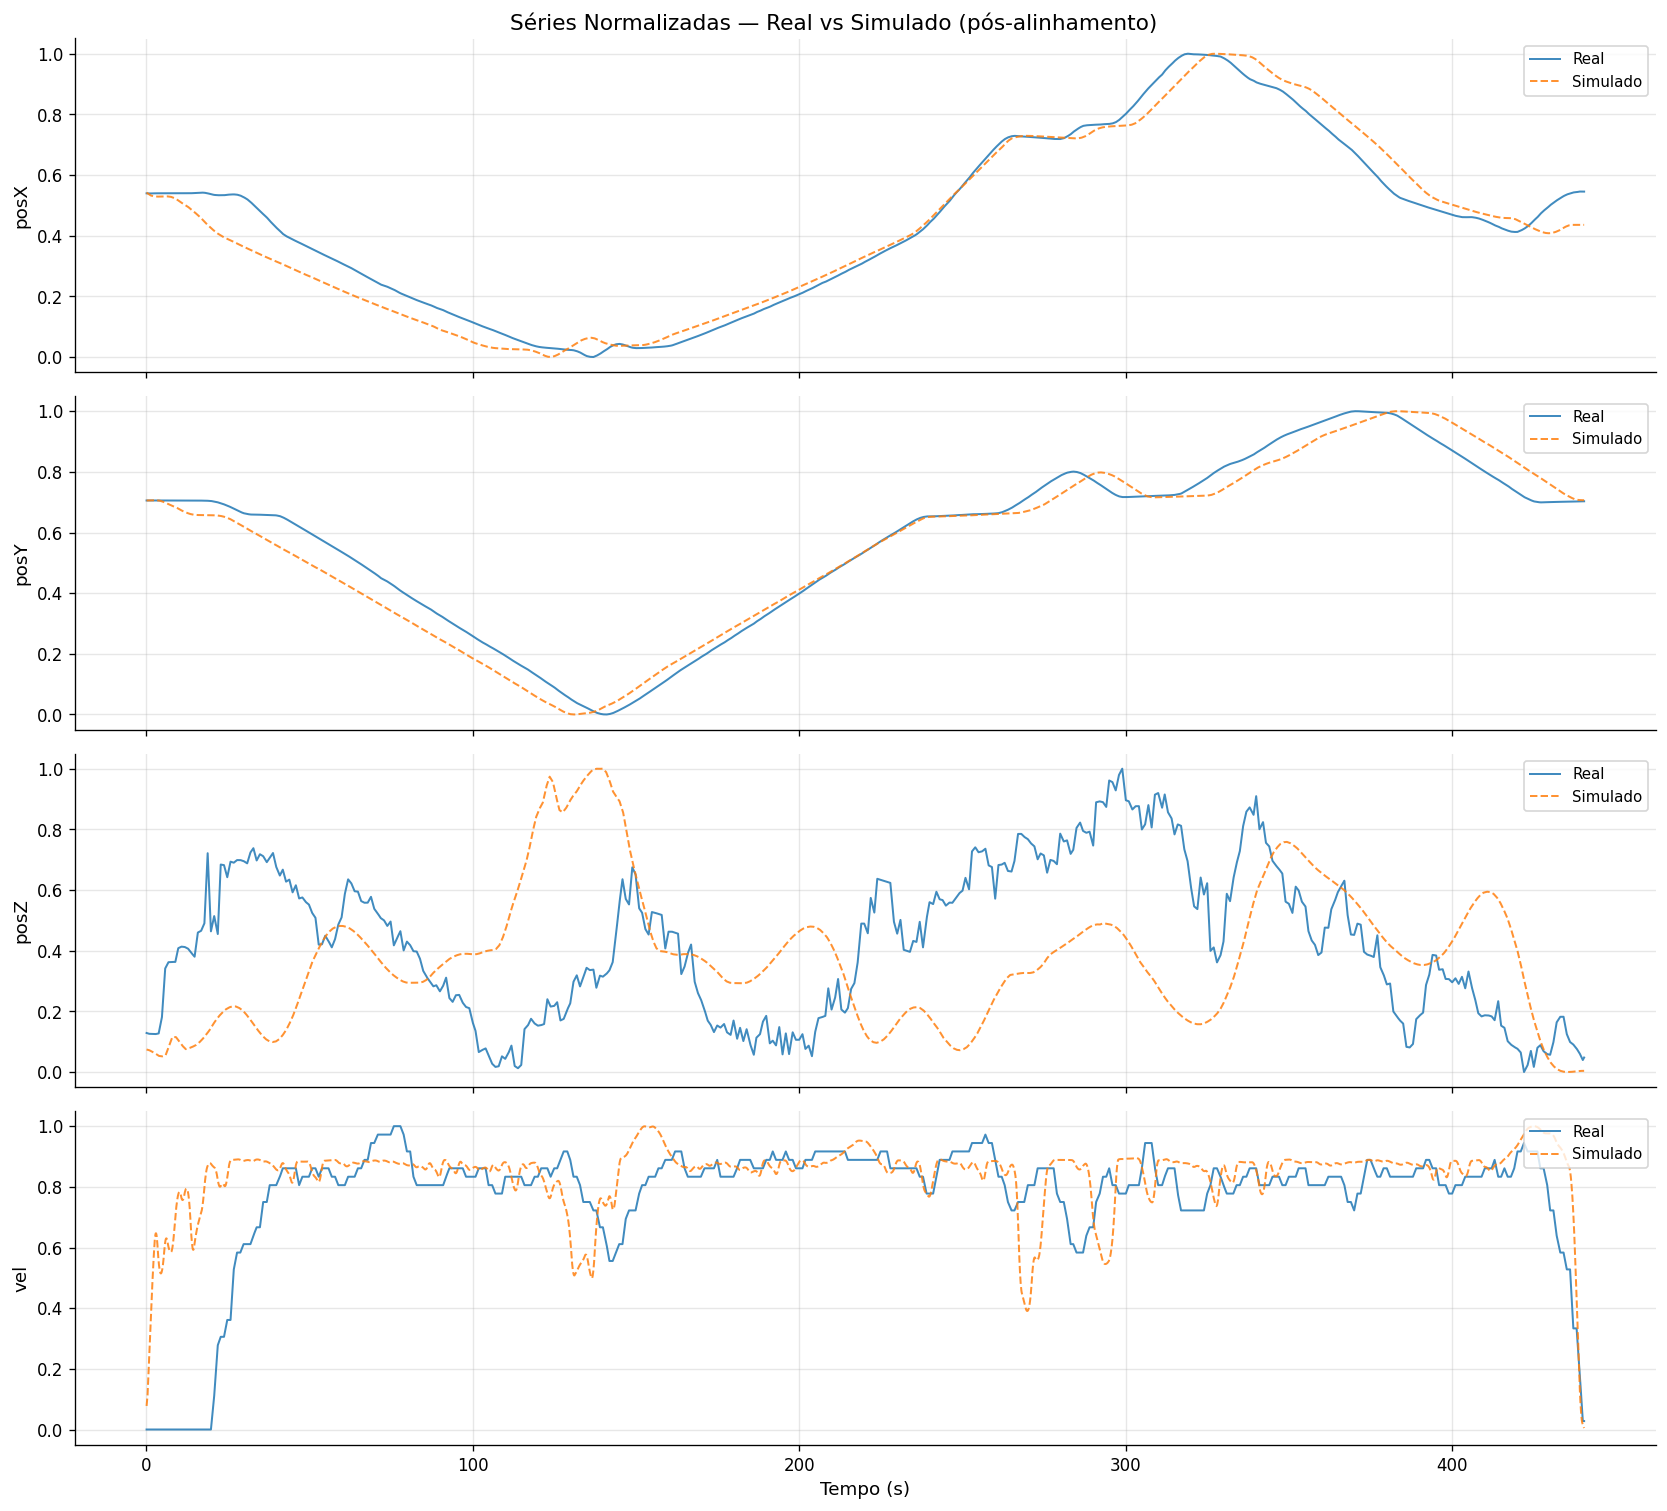

In [7]:
t = df.index.total_seconds().values

fig, axes = plt.subplots(len(colunas_corr), 1, figsize=(14, 3.2 * len(colunas_corr)), sharex=True)

for ax, col in zip(axes, colunas_corr):
    ax.plot(t, df[f'real_{col}'],         label='Real',      color='#1f77b4', lw=1.2, alpha=0.85)
    ax.plot(t, df[f'sim_{col}_shifted'],  label='Simulado',  color='#ff7f0e', lw=1.2, alpha=0.85, ls='--')
    ax.set_ylabel(col, fontsize=11)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Tempo (s)', fontsize=11)
fig.suptitle('Séries Normalizadas — Real vs Simulado (pós-alinhamento)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Trajetória espacial

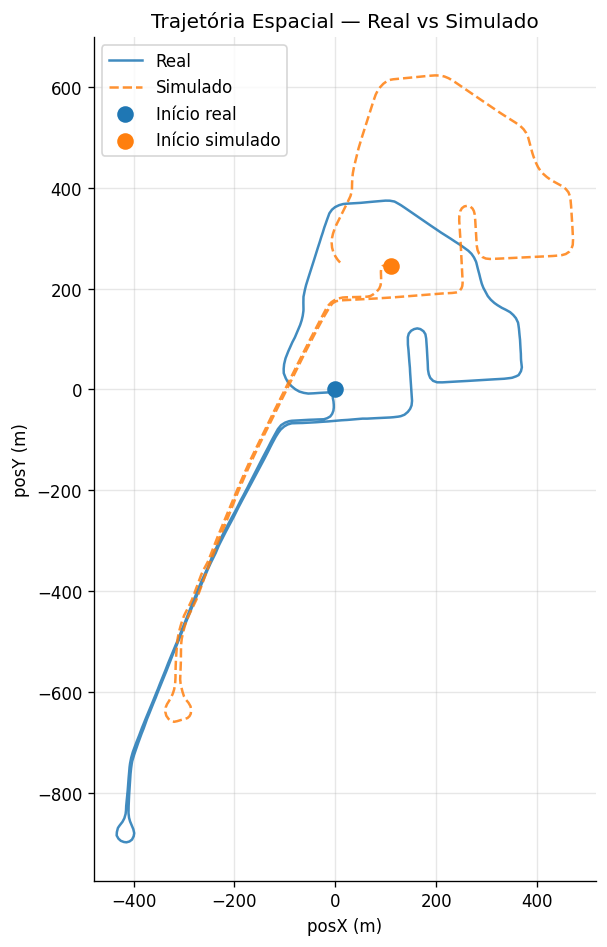

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(real_c['posX'],  real_c['posY'],  label='Real',     color='#1f77b4', lw=1.5, alpha=0.85)
ax.plot(sim_c['posX'],   sim_c['posY'],   label='Simulado', color='#ff7f0e', lw=1.5, alpha=0.85, ls='--')
ax.scatter(real_c['posX'].iloc[0],  real_c['posY'].iloc[0],  color='#1f77b4', s=80, zorder=5, label='Início real')
ax.scatter(sim_c['posX'].iloc[0],   sim_c['posY'].iloc[0],   color='#ff7f0e', s=80, zorder=5, label='Início simulado')
ax.set_xlabel('posX (m)')
ax.set_ylabel('posY (m)')
ax.set_title('Trajetória Espacial — Real vs Simulado')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 9. Pearson — correlação linear global

Mede o quanto as duas séries variam juntas de forma linear.
**r próximo de 1** = alta correlação positiva (simulado sobe quando real sobe).
**Limitação**: sensível a outliers e assume relação linear.

In [9]:
pearson_resultados = {}

print(f"{'Variável':<10} {'r':>8} {'p-value':>12}  Interpretação")
print('-' * 60)

for col in colunas_corr:
    x  = df[f'real_{col}'].values
    ys = df[f'sim_{col}_shifted'].values
    r, p = pearsonr(x, ys)
    pearson_resultados[col] = {'r': r, 'p': p}

    if abs(r) >= 0.85:   interp = 'Muito forte'
    elif abs(r) >= 0.70: interp = 'Forte'
    elif abs(r) >= 0.50: interp = 'Moderada'
    elif abs(r) >= 0.30: interp = 'Fraca'
    else:                interp = 'Sem correlação'

    sig = '(significativo)' if p < 0.05 else '(NÃO significativo)'
    print(f"{col:<10} {r:>8.4f} {p:>12.2e}  {interp} {sig}")

Variável          r      p-value  Interpretação
------------------------------------------------------------
posX         0.9793     0.00e+00  Muito forte (significativo)
posY         0.9815     0.00e+00  Muito forte (significativo)
posZ        -0.0885     4.05e-09  Sem correlação (significativo)
vel          0.4672    1.29e-237  Fraca (significativo)


## 10. DTW — similaridade com alinhamento temporal flexível

O DTW encontra o melhor alinhamento possível entre as duas séries,
mesmo que uma esteja adiantada ou atrasada de forma não-uniforme.
**Distância 0** = séries idênticas. **Similaridade 1** = idênticas.
**Vantagem sobre Pearson**: não assume linearidade nem alinhamento perfeito.
**Limitação**: mais lento computacionalmente; não fornece p-value.

In [10]:
dtw_resultados = {}

print(f"{'Variável':<10} {'Distância':>12} {'Dist. norm.':>12} {'Similaridade':>14}  Interpretação")
print('-' * 75)

for col in colunas_corr:
    x  = df[f'real_{col}'].values.astype(np.double)
    ys = df[f'sim_{col}_shifted'].values.astype(np.double)

    dist  = dtw.distance_fast(x, ys, use_pruning=True)
    norm  = dist / len(x)                  # normaliza pelo número de amostras
    sim   = 1.0 / (1.0 + norm)             # converte para [0,1]

    dtw_resultados[col] = {'dist': dist, 'norm': norm, 'sim': sim}

    if sim >= 0.90:   interp = 'Muito similar'
    elif sim >= 0.80: interp = 'Similar'
    elif sim >= 0.65: interp = 'Moderadamente similar'
    else:             interp = 'Pouco similar'

    print(f"{col:<10} {dist:>12.4f} {norm:>12.6f} {sim:>14.4f}  {interp}")

# DTW 2D: trajetória espacial (posX + posY juntos)
print()
print('DTW 2D — trajetória espacial (posX + posY combinados):')
traj_r = np.column_stack([df['real_posX'].values, df['real_posY'].values]).astype(np.double)
traj_s = np.column_stack([df['sim_posX_shifted'].values, df['sim_posY_shifted'].values]).astype(np.double)
dist2d = dtw_ndim.distance_fast(traj_r, traj_s)
norm2d = dist2d / len(traj_r)
sim2d  = 1.0 / (1.0 + norm2d)
print(f"  posX+posY: dist={dist2d:.4f}  norm={norm2d:.4f}  similaridade={sim2d:.4f}")

Variável      Distância  Dist. norm.   Similaridade  Interpretação
---------------------------------------------------------------------------
posX             1.0425     0.000237         0.9998  Muito similar
posY             0.0693     0.000016         1.0000  Muito similar
posZ             5.7950     0.001316         0.9987  Muito similar
vel              2.5337     0.000576         0.9994  Muito similar

DTW 2D — trajetória espacial (posX + posY combinados):
  posX+posY: dist=1.2065  norm=0.0003  similaridade=0.9997


## 11. ANOVA — teste de igualdade de distribuição por segmento

Divide o percurso em N segmentos iguais e aplica ANOVA em cada um.
**H0 (hipótese nula)**: real e simulado têm a mesma média no segmento.
**p < 0.05**: rejeita H0 → as distribuições são significativamente diferentes.
**Vantagem**: identifica *onde* no percurso o simulado diverge estatisticamente.
**Limitação**: assume que os dados em cada segmento são independentes e normais.

In [11]:
N_SEGMENTOS = 10   # divide o percurso em 10 partes iguais

anova_resultados = {}   # {col: [(seg_inicio_s, seg_fim_s, F, p)]}
n = len(df)
seg_size = n // N_SEGMENTOS
t_seg = df.index.total_seconds().values

print(f'Segmentos: {N_SEGMENTOS} × {seg_size} amostras ({seg_size * 0.1:.0f}s cada)')
print()

for col in colunas_corr:
    x  = df[f'real_{col}'].values
    ys = df[f'sim_{col}_shifted'].values
    segs = []

    print(f'--- {col} ---')
    print(f"  {'Segmento':<18} {'F':>8} {'p-value':>12}  Resultado")

    for i in range(N_SEGMENTOS):
        ini = i * seg_size
        fim = ini + seg_size if i < N_SEGMENTOS - 1 else n
        xi  = x[ini:fim]
        yi  = ys[ini:fim]

        t_ini = t_seg[ini]
        t_fim = t_seg[min(fim - 1, n - 1)]

        if np.std(xi) < 1e-10 and np.std(yi) < 1e-10:
            F, p = 0.0, 1.0
        else:
            F, p = f_oneway(xi, yi)

        resultado = '✗ Diferente (p<0.05)' if p < 0.05 else '✓ Similar  (p≥0.05)'
        segs.append({'ini': t_ini, 'fim': t_fim, 'F': F, 'p': p})
        print(f"  {t_ini:6.0f}s – {t_fim:6.0f}s   {F:>8.2f} {p:>12.2e}  {resultado}")

    anova_resultados[col] = segs
    pct_dif = sum(1 for s in segs if s['p'] < 0.05) / N_SEGMENTOS * 100
    print(f"  → {pct_dif:.0f}% dos segmentos com diferença significativa\n")

Segmentos: 10 × 440 amostras (44s cada)

--- posX ---
  Segmento                  F      p-value  Resultado
       0s –     44s     434.87     9.20e-79  ✗ Diferente (p<0.05)
      44s –     88s     379.71     1.47e-70  ✗ Diferente (p<0.05)
      88s –    132s     259.20     2.70e-51  ✗ Diferente (p<0.05)
     132s –    176s     210.63     6.14e-43  ✗ Diferente (p<0.05)
     176s –    220s      34.52     6.00e-09  ✗ Diferente (p<0.05)
     220s –    264s       0.10     7.58e-01  ✓ Similar  (p≥0.05)
     264s –    308s      59.76     2.92e-14  ✗ Diferente (p<0.05)
     308s –    352s       0.66     4.15e-01  ✓ Similar  (p≥0.05)
     352s –    396s     111.84     1.10e-24  ✗ Diferente (p<0.05)
     396s –    440s      35.12     4.43e-09  ✗ Diferente (p<0.05)
  → 80% dos segmentos com diferença significativa

--- posY ---
  Segmento                  F      p-value  Resultado
       0s –     44s     326.26     2.95e-62  ✗ Diferente (p<0.05)
      44s –     88s     277.40     2.47e-54  ✗ Dif

## 12. Visualização ANOVA — mapa de divergência por segmento

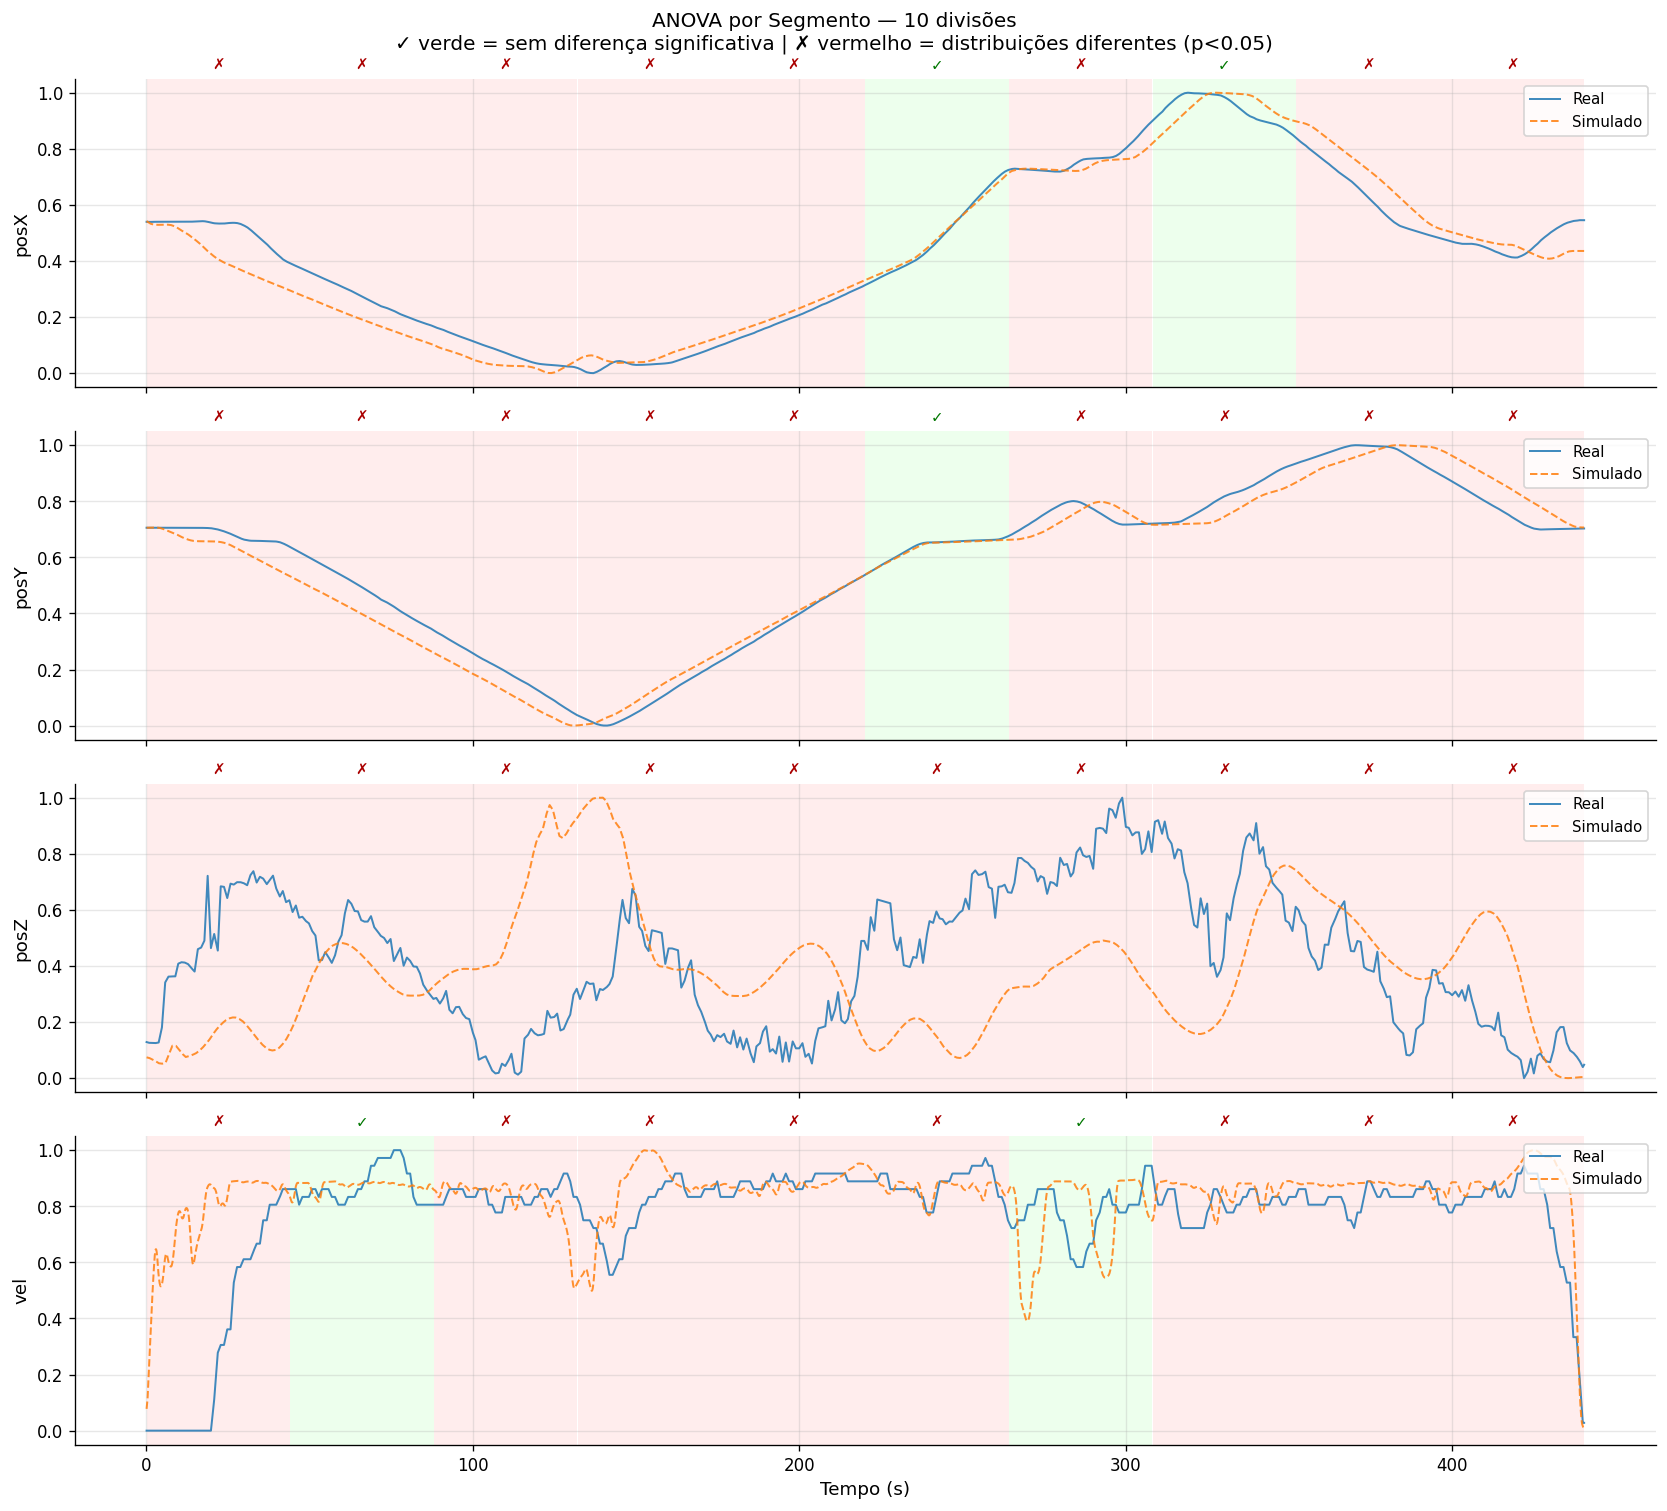

In [12]:
fig, axes = plt.subplots(len(colunas_corr), 1, figsize=(14, 3.2 * len(colunas_corr)), sharex=True)

for ax, col in zip(axes, colunas_corr):
    x  = df[f'real_{col}'].values
    ys = df[f'sim_{col}_shifted'].values

    ax.plot(t, x,  label='Real',     color='#1f77b4', lw=1.2, alpha=0.85)
    ax.plot(t, ys, label='Simulado', color='#ff7f0e', lw=1.2, alpha=0.85, ls='--')

    # Pintar fundo de cada segmento conforme o resultado ANOVA
    for seg in anova_resultados[col]:
        cor   = '#ffcccc' if seg['p'] < 0.05 else '#ccffcc'
        label = f"p={seg['p']:.2e}"
        ax.axvspan(seg['ini'], seg['fim'], alpha=0.35, color=cor, lw=0)
        ax.text(
            (seg['ini'] + seg['fim']) / 2, 1.02,
            '✗' if seg['p'] < 0.05 else '✓',
            ha='center', va='bottom', fontsize=9,
            color='#aa0000' if seg['p'] < 0.05 else '#007700',
            transform=ax.get_xaxis_transform()
        )

    ax.set_ylabel(col, fontsize=11)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Tempo (s)', fontsize=11)
fig.suptitle(
    f'ANOVA por Segmento — {N_SEGMENTOS} divisões\n'
    '✓ verde = sem diferença significativa | ✗ vermelho = distribuições diferentes (p<0.05)',
    fontsize=12
)
plt.tight_layout()
plt.show()

## 13. Resumo comparativo final — Pearson × DTW × ANOVA

In [13]:
# ── Tabela resumo ─────────────────────────────────────────────────────────────
print('=' * 80)
print('RESUMO — Pearson × DTW × ANOVA')
print('=' * 80)
print(f"{'Variável':<10} {'Pearson r':>10} {'DTW sim':>10} {'ANOVA dif%':>12}  Veredicto")
print('-' * 80)

def veredicto(r, sim, pct_dif):
    if r > 0.85 and sim > 0.85 and pct_dif <= 20:
        return '✓ VÁLIDO — todas as métricas aprovam'
    elif r > 0.70 and sim > 0.70 and pct_dif <= 50:
        return '~ ACEITÁVEL — divergências pontuais'
    elif r > 0.50 or sim > 0.70:
        return '? PARCIAL — métricas discordam, investigar'
    else:
        return '✗ INVÁLIDO — simulado não reproduz o real'

for col in colunas_corr:
    r      = pearson_resultados[col]['r']
    sim    = dtw_resultados[col]['sim']
    segs   = anova_resultados[col]
    pct_dif = sum(1 for s in segs if s['p'] < 0.05) / len(segs) * 100
    verd   = veredicto(r, sim, pct_dif)
    print(f"{col:<10} {r:>10.4f} {sim:>10.4f} {pct_dif:>11.0f}%  {verd}")

print('=' * 80)
print()
print(f'DTW 2D trajetória (posX+posY): similaridade = {sim2d:.4f}')
print()
print('Legenda:')
print('  Pearson r   → correlação linear [-1, 1] (1 = perfeita)')
print('  DTW sim     → similaridade com alinhamento flexível [0, 1] (1 = idêntico)')
print('  ANOVA dif%  → % de segmentos onde as distribuições são significativamente diferentes')
print('  throttle    → excluído (depende do motorista, não do veículo)')

RESUMO — Pearson × DTW × ANOVA
Variável    Pearson r    DTW sim   ANOVA dif%  Veredicto
--------------------------------------------------------------------------------
posX           0.9793     0.9998          80%  ? PARCIAL — métricas discordam, investigar
posY           0.9815     1.0000          90%  ? PARCIAL — métricas discordam, investigar
posZ          -0.0885     0.9987         100%  ? PARCIAL — métricas discordam, investigar
vel            0.4672     0.9994          80%  ? PARCIAL — métricas discordam, investigar

DTW 2D trajetória (posX+posY): similaridade = 0.9997

Legenda:
  Pearson r   → correlação linear [-1, 1] (1 = perfeita)
  DTW sim     → similaridade com alinhamento flexível [0, 1] (1 = idêntico)
  ANOVA dif%  → % de segmentos onde as distribuições são significativamente diferentes
  throttle    → excluído (depende do motorista, não do veículo)


## 14. Gráfico de barras comparativo — visão geral das três métricas

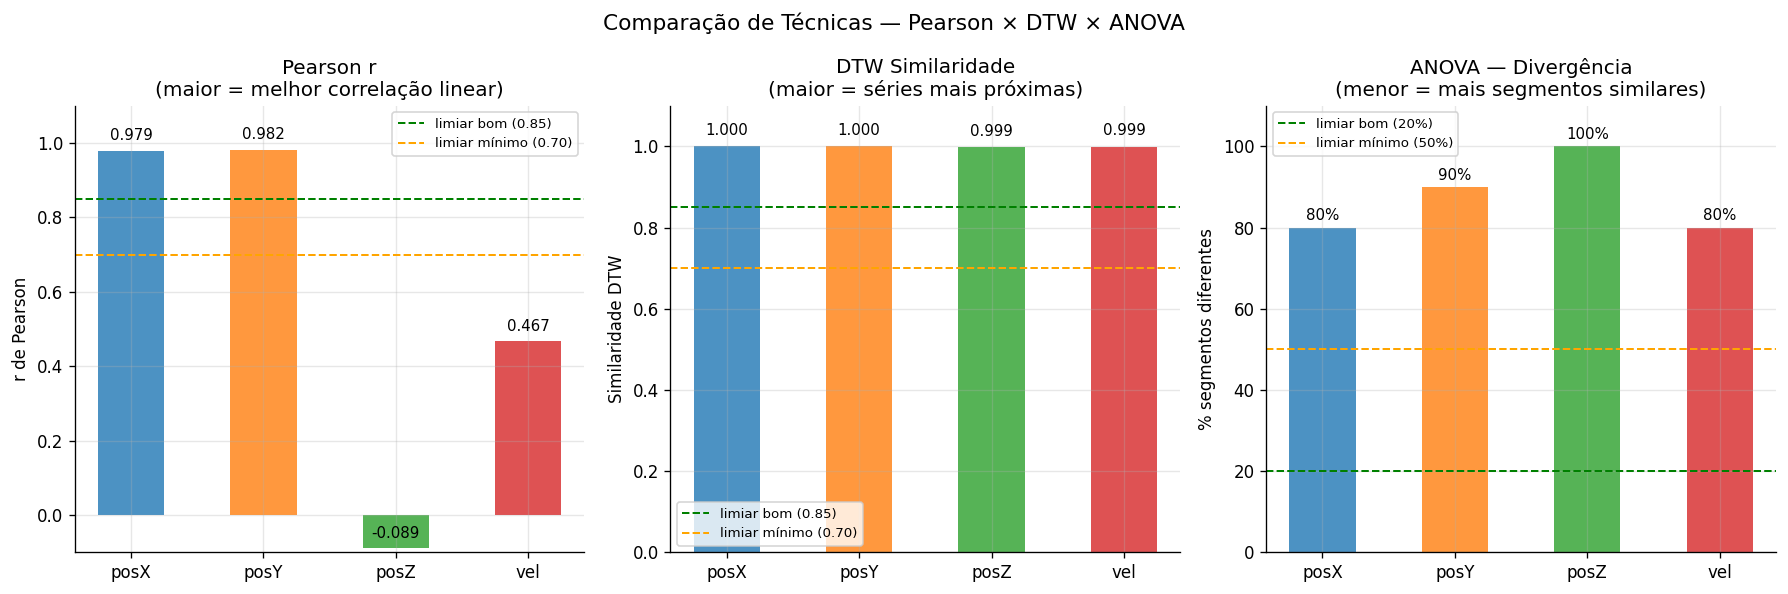

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cores_var = {'posX': '#1f77b4', 'posY': '#ff7f0e', 'posZ': '#2ca02c', 'vel': '#d62728'}
x_pos = np.arange(len(colunas_corr))

# ── Pearson r ────────────────────────────────────────────────────────────────
ax = axes[0]
vals = [pearson_resultados[c]['r'] for c in colunas_corr]
bars = ax.bar(x_pos, vals, color=[cores_var[c] for c in colunas_corr], alpha=0.8, width=0.5)
ax.axhline(0.85, color='green',  ls='--', lw=1.2, label='limiar bom (0.85)')
ax.axhline(0.70, color='orange', ls='--', lw=1.2, label='limiar mínimo (0.70)')
ax.set_ylim(-0.1, 1.1)
ax.set_xticks(x_pos)
ax.set_xticklabels(colunas_corr)
ax.set_ylabel('r de Pearson')
ax.set_title('Pearson r\n(maior = melhor correlação linear)')
ax.legend(fontsize=8)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# ── DTW Similaridade ─────────────────────────────────────────────────────────
ax = axes[1]
vals = [dtw_resultados[c]['sim'] for c in colunas_corr]
bars = ax.bar(x_pos, vals, color=[cores_var[c] for c in colunas_corr], alpha=0.8, width=0.5)
ax.axhline(0.85, color='green',  ls='--', lw=1.2, label='limiar bom (0.85)')
ax.axhline(0.70, color='orange', ls='--', lw=1.2, label='limiar mínimo (0.70)')
ax.set_ylim(0, 1.1)
ax.set_xticks(x_pos)
ax.set_xticklabels(colunas_corr)
ax.set_ylabel('Similaridade DTW')
ax.set_title('DTW Similaridade\n(maior = séries mais próximas)')
ax.legend(fontsize=8)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# ── ANOVA % diferente ────────────────────────────────────────────────────────
ax = axes[2]
vals = [
    sum(1 for s in anova_resultados[c] if s['p'] < 0.05) / len(anova_resultados[c]) * 100
    for c in colunas_corr
]
bars = ax.bar(x_pos, vals, color=[cores_var[c] for c in colunas_corr], alpha=0.8, width=0.5)
ax.axhline(20,  color='green',  ls='--', lw=1.2, label='limiar bom (20%)')
ax.axhline(50,  color='orange', ls='--', lw=1.2, label='limiar mínimo (50%)')
ax.set_ylim(0, 110)
ax.set_xticks(x_pos)
ax.set_xticklabels(colunas_corr)
ax.set_ylabel('% segmentos diferentes')
ax.set_title('ANOVA — Divergência\n(menor = mais segmentos similares)')
ax.legend(fontsize=8)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9)

fig.suptitle('Comparação de Técnicas — Pearson × DTW × ANOVA', fontsize=13)
plt.tight_layout()
plt.show()